# Heavy Vehicle Failure Prediction Through Intelligent Sensor Data Analysis

## Exploratory Data Analysis and Data Preprocessing — APS Scania Dataset

**Dataset:** APS Failure at Scania Trucks  
**Target:** `class`  
**Task:** Binary classification of APS-related failure (`pos`) vs. non-APS-related failure (`neg`)

> This notebook intentionally starts from the combined raw dataset. Preprocessing decisions are made from EDA results and are fitted using training data only where appropriate to avoid data leakage.


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")


## 2. Load Dataset

In [3]:
# Update this path if your CSV is stored somewhere else
DATA_PATH = "D:\\ML\\HEAVY VEHICLE FAILURE PREDICTION THROUGH INTELLIGENT SENSOR\\dataset\\APS_Scania_Complete_Dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)


Dataset loaded successfully!
Shape: (76000, 171)


## 3. Initial Dataset Inspection

In [4]:
display(df.head())
display(df.tail())

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_006,ag_007,ag_008,ag_009,ah_000,ai_000,aj_000,ak_000,al_000,am_0,an_000,ao_000,ap_000,aq_000,ar_000,as_000,at_000,au_000,av_000,ax_000,ay_000,ay_001,ay_002,ay_003,ay_004,ay_005,ay_006,ay_007,ay_008,ay_009,az_000,az_001,az_002,az_003,az_004,az_005,az_006,az_007,az_008,az_009,ba_000,ba_001,ba_002,ba_003,ba_004,ba_005,ba_006,ba_007,ba_008,ba_009,bb_000,bc_000,bd_000,be_000,bf_000,bg_000,bh_000,bi_000,bj_000,bk_000,bl_000,bm_000,bn_000,bo_000,bp_000,bq_000,br_000,bs_000,bt_000,bu_000,bv_000,bx_000,by_000,bz_000,ca_000,cb_000,cc_000,cd_000,ce_000,cf_000,cg_000,ch_000,ci_000,cj_000,ck_000,cl_000,cm_000,cn_000,cn_001,cn_002,cn_003,cn_004,cn_005,cn_006,cn_007,cn_008,cn_009,co_000,cp_000,cq_000,cr_000,cs_000,cs_001,cs_002,cs_003,cs_004,cs_005,cs_006,cs_007,cs_008,cs_009,ct_000,cu_000,cv_000,cx_000,cy_000,cz_000,da_000,db_000,dc_000,dd_000,de_000,df_000,dg_000,dh_000,di_000,dj_000,dk_000,dl_000,dm_000,dn_000,do_000,dp_000,dq_000,dr_000,ds_000,dt_000,du_000,dv_000,dx_000,dy_000,dz_000,ea_000,eb_000,ec_00,ed_000,ee_000,ee_001,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,na,2130706438,280,0,0,0,0,0,0,37250,1432864,3664156,1007684,25896,0,2551696,0,0,0,0,0,4933296,3655166,1766008,1132040,0,0,0,0,1012,268,0,0,0,0,0,469014,4239660,703300,755876,0,5374,2108,4114,12348,615248,5526276,2378,4,0,0,2328746,1022304,415432,287230,310246,681504,1118814,3574,0,0,6700214,0,10,108,50,2551696,97518,947550,799478,330760,353400,299160,305200,283680,na,na,na,178540,76698.08,6700214,6700214,6599892,43566,68656,54064,638360,6167850,1209600,246244,2,96,0,5245752,0,916567.68,6,1924,0,0,0,118196,1309472,3247182,1381362,98822,11208,1608,220,240,6700214,na,10476,1226,267998,521832,428776,4015854,895240,26330,118,0,532,734,4122704,51288,0,532572,0,18,5330690,4732,1126,0,0,0,0,0,0,0,0,62282,85908,32790,0,0,202710,37928,14745580,1876644,0,0,0,0,2801180,2445.8,2712,965866,1706908,1240520,493384,721044,469792,339156,157956,73224,0,0,0
1,neg,33058,na,0,na,0,0,0,0,0,0,18254,653294,1720800,516724,31642,0,1393352,0,68,0,0,0,2560898,2127150,1084598,338544,0,0,0,0,0,0,0,0,0,0,0,71510,772720,1996924,99560,0,7336,7808,13776,13086,1010074,1873902,14726,6,0,0,1378576,447166,199512,154298,137280,138668,165908,229652,87082,4708,3646660,86,454,364,350,1393352,49028,688314,392208,341420,359780,366560,na,na,na,na,na,6700,33057.51,3646660,3646660,3582034,17733.0,260120,115626,6900,2942850,1209600,0,na,na,na,2291079.36,0,643536.96,0,0,0,0,38,98644,1179502,1286736,336388,36294,5192,56,na,0,3646660,na,6160,796,164860,350066,272956,1837600,301242,9148,22,0,na,na,na,na,na,na,na,na,na,3312,522,0,0,0,0,0,0,0,0,33736,36946,5936,0,0,103330,16254,4510080,868538,0,0,0,0,3477820,2211.76,2334,664504,824154,421400,178064,293306,245416,133654,81140,97576,1500,0,0
2,neg,41040,na,228,100,0,0,0,0,0,0,1648,370592,1883374,292936,12016,0,1234132,0,0,0,0,0,2371990,2173634,300796,153698,0,0,0,0,358,110,0,0,0,0,0,0,870456,239798,1450312,0,1620,1156,1228,34250,1811606,710672,34,0,0,0,790690,672026,332340,254892,189596,135758,103552,81666,46,0,2673338,128,202,576,4,1234132,28804,160176,139730,137160,130640,na,na,na,na,na,na,28000,41040.08,2673338,2673338,2678534,15439.0,7466,22436,248240,2560566,1209600,63328,0,124,0,2322692.16,0,236099.52,0,0,0,0,0,33276,1215280,1102798,196502,10260,2422,28,0,6,2673338,na,3584,500,56362,149726,100326,1744838,488302,16682,246,0,230,292,2180528,29188,22,20346,0,0,2341048,1494,152,0,0,0,0,0,0,0,0,13876,38182,8138,0,0,65772,10534,300240,48028,0,0,0,0,1040120,1018.64,1020,262032,453378,277378,159812,423992,409564,320746,158022,95128,514,0,0
3,neg,12,0,70,66,0,10,0,0,0,318,2212,3232,1872,0,0,0,2668,0,0,0,642,3894,10184,7554,10764,1014,0,0,0,0,60,6,0,0,0,0,0,0,0,2038,5596,0,64,6,6,914,76,2478,2398,1692,0,0,6176,340,304,102,74,406,216,16,0,0,21614,2,12,0,0,2668,184,7632,3090,na,na,na,na,na,na,na,na,10580,12.69,21614,21614,21772,32,50,1994,21400,7710,120960

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_006,ag_007,ag_008,ag_009,ah_000,ai_000,aj_000,ak_000,al_000,am_0,an_000,ao_000,ap_000,aq_000,ar_000,as_000,at_000,au_000,av_000,ax_000,ay_000,ay_001,ay_002,ay_003,ay_004,ay_005,ay_006,ay_007,ay_008,ay_009,az_000,az_001,az_002,az_003,az_004,az_005,az_006,az_007,az_008,az_009,ba_000,ba_001,ba_002,ba_003,ba_004,ba_005,ba_006,ba_007,ba_008,ba_009,bb_000,bc_000,bd_000,be_000,bf_000,bg_000,bh_000,bi_000,bj_000,bk_000,bl_000,bm_000,bn_000,bo_000,bp_000,bq_000,br_000,bs_000,bt_000,bu_000,bv_000,bx_000,by_000,bz_000,ca_000,cb_000,cc_000,cd_000,ce_000,cf_000,cg_000,ch_000,ci_000,cj_000,ck_000,cl_000,cm_000,cn_000,cn_001,cn_002,cn_003,cn_004,cn_005,cn_006,cn_007,cn_008,cn_009,co_000,cp_000,cq_000,cr_000,cs_000,cs_001,cs_002,cs_003,cs_004,cs_005,cs_006,cs_007,cs_008,cs_009,ct_000,cu_000,cv_000,cx_000,cy_000,cz_000,da_000,db_000,dc_000,dd_000,de_000,df_000,dg_000,dh_000,di_000,dj_000,dk_000,dl_000,dm_000,dn_000,do_000,dp_000,dq_000,dr_000,ds_000,dt_000,du_000,dv_000,dx_000,dy_000,dz_000,ea_000,eb_000,ec_00,ed_000,ee_000,ee_001,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
75995,neg,81852,na,2130706432,892,0,0,0,0,0,0,5486,704012,3220278,1297498,76170,7206,2276100,0,0,0,0,0,4547950,3779700,973592,669608,0,0,1536,0,6374,1194,0,0,0,0,0,214014,3876498,868212,351926,0,4622,2328,2176,3048,321282,4976848,346,0,0,0,1591426,1335362,346644,248082,183738,162876,299794,1141712,1016,0,5522314,6476,8936,1626,102,2276100,68662,475928,493980,239020,228440,202320,194800,na,na,na,na,99940,81851.77,5522314,5522314,5510074,42112,1116,60896,674580,5310650,1209600,162502,2,138,0,4457943.36,0,847887.36,0,1192,0,0,0,94218,1403348,2787108,947254,67132,10262,1328,42,54,5522314,na,8922,1066,357990,397290,522352,3630086,384992,7896,56,0,1352,3336,4488552,1124612,0,64940,0,12,4521542,4596,1006,0,0,0,0,0,0,0,0,40386,58588,23628,0,0,155596,23350,7124860,724280,30954,6854,0,0,10074490,1546.74,2054,883900,983308,632658,273242,510354,373918,349840,317840,960024,25566,0,0
75996,neg,18,0,52,46,8,26,0,0,0,0,6444,3308,2720,0,0,0,3740,0,0,0,1150,2790,14656,12242,7222,1338,0,0,0,0,66,96,0,0,0,0,0,0,0,2114,10358,0,60,6,10,1012,14,2492,8878,0,0,0,10942,506,300,122,50,374,178,0,0,0,23062,8,18,34,0,3740,240,2932,4264,na,na,na,na,na,na,na,na,7080,18.41,23062,23062,24920,38,0,2176,22860,12536,1209600,450,2,10,0,3330.24,0,8124.48,2,20,0,0,6376,1516,3394,1162,24,0,0,0,0,0,23062,0,1086,6,16,306,2504,8294,260,0,0,0,118,274,3938,220,0,52,0,0,3962,104,66,0,0,0,0,0,0,0,0,264,0,0,32,8,106,28,3500,340,11108,8,0,0,0,0.98,50,9354,2746,266,44,46,14,2,0,0,0,0,0
75997,neg,79636,na,1670,1518,0,0,0,0,0,0,15062,1991298,2768440,329148,13124,990,2156280,0,0,0,0,0,4562338,3828492,1238380,578006,0,0,1828,0,8044,1130,0,0,0,0,0,1686138,3101858,315250,14816,0,5660,1544,2580,349324,3735962,1022956,36,0,0,0,1489006,1223696,459728,362492,301912,279664,498804,502756,4,0,5802262,26,2544,372,68,2156280,63754,817038,419172,225360,277120,300460,288340,na,na,na,na,131960,79635.97,5802262,5802262,5733332,38013.0,2688,84746,947380,5118062,1209600,194480,2,76,0,4694372.16,0,417673.92,0,0,0,0,0,468284,2390738,1884936,339562,26948,6752,842,378,930,5802262,na,10982,1408,37980,162396,233722,3498272,1127556,45170,576,0,2272,3242,4637846,55486,0,3468,208,42,4728848,5108,456,0,0,0,0,0,0,0,0,40850,114166,18210,0,0,187506,29150,439500,51928,952030,7626,0,0,715020,3644.6,3982,450380,1073658,806832,449962,778826,581558,375498,222866,358934,19548,0,0
75998,neg,110,na,36,32,0,0,0,0,0,0,198,3730,27418,978,0,0,12790,0,0,0,0,0,26026,13504,61018,6160,0,0,0,0,22,66,0,0,0,0,0,0,0,14678,17646,0,274,192,292,302,5752,25512,0,0,0,0,27052,2742,1028,472,238,164,344,284,0,0,87120,2,10,18,0,12790,602,46216,14332,na,na,na,na,na,na,na,na,60280,109.52,87120,87120,85224,76,0,8198,86460,32324,1209600,1194,0,8,0,10367.04,0,20952,0,42,0,0,0,2418,21662,6816,1262,162,4,0,0,12,87120,na,1158,60,84,2206,2008,8598,15958,2192,60,0,14,194,12680,

Rows: 76000
Columns: 171


In [5]:
print("Column names:")
print(df.columns.tolist())


Column names:
['class', 'aa_000', 'ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000', 'ag_000', 'ag_001', 'ag_002', 'ag_003', 'ag_004', 'ag_005', 'ag_006', 'ag_007', 'ag_008', 'ag_009', 'ah_000', 'ai_000', 'aj_000', 'ak_000', 'al_000', 'am_0', 'an_000', 'ao_000', 'ap_000', 'aq_000', 'ar_000', 'as_000', 'at_000', 'au_000', 'av_000', 'ax_000', 'ay_000', 'ay_001', 'ay_002', 'ay_003', 'ay_004', 'ay_005', 'ay_006', 'ay_007', 'ay_008', 'ay_009', 'az_000', 'az_001', 'az_002', 'az_003', 'az_004', 'az_005', 'az_006', 'az_007', 'az_008', 'az_009', 'ba_000', 'ba_001', 'ba_002', 'ba_003', 'ba_004', 'ba_005', 'ba_006', 'ba_007', 'ba_008', 'ba_009', 'bb_000', 'bc_000', 'bd_000', 'be_000', 'bf_000', 'bg_000', 'bh_000', 'bi_000', 'bj_000', 'bk_000', 'bl_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000', 'bs_000', 'bt_000', 'bu_000', 'bv_000', 'bx_000', 'by_000', 'bz_000', 'ca_000', 'cb_000', 'cc_000', 'cd_000', 'ce_000', 'cf_000', 'cg_000', 'ch_000', 'ci_000', 'cj_000', 'ck_000', 'cl_000'

In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Columns: 171 entries, class to eg_000
dtypes: int64(1), str(170)
memory usage: 99.2 MB


## 4. Target Variable Analysis

The `class` column is the prediction target:

- `neg` → failure is not related to the APS component
- `pos` → failure is related to the APS component


In [7]:
class_counts = df["class"].value_counts(dropna=False)
class_percent = df["class"].value_counts(normalize=True, dropna=False) * 100

print("Class counts:")
display(class_counts)

print("Class percentages:")
display(class_percent.round(2))


Class counts:


class
neg    74625
pos     1375
Name: count, dtype: int64

Class percentages:


class
neg    98.19
pos     1.81
Name: proportion, dtype: float64

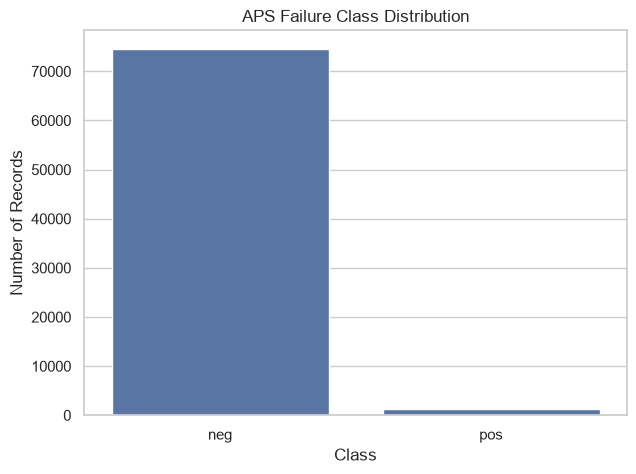

In [8]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="class")
plt.title("APS Failure Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Records")
plt.show()


### EDA Observation

The target distribution should be checked for class imbalance. APS failure prediction is expected to be highly imbalanced, so accuracy alone should not be used to judge the final model.


## 5. Raw Missing-Value Analysis

In [9]:
# In the original APS data, missing values are represented by the string "na".
missing_count_raw = (df == "na").sum()
missing_percentage_raw = (missing_count_raw / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing_Count": missing_count_raw,
    "Missing_Percentage": missing_percentage_raw
}).sort_values("Missing_Percentage", ascending=False)

display(missing_summary.head(30))


,Missing_Count,Missing_Percentage
br_000,62393,82.096053
bq_000,61703,81.188158
bp_000,60461,79.553947
bo_000,58709,77.248684
ab_000,58692,77.226316
cr_000,58692,77.226316
bn_000,55722,73.318421
bm_000,50095,65.914474
bl_000,34503,45.398684
bk_000,29128,38.326316


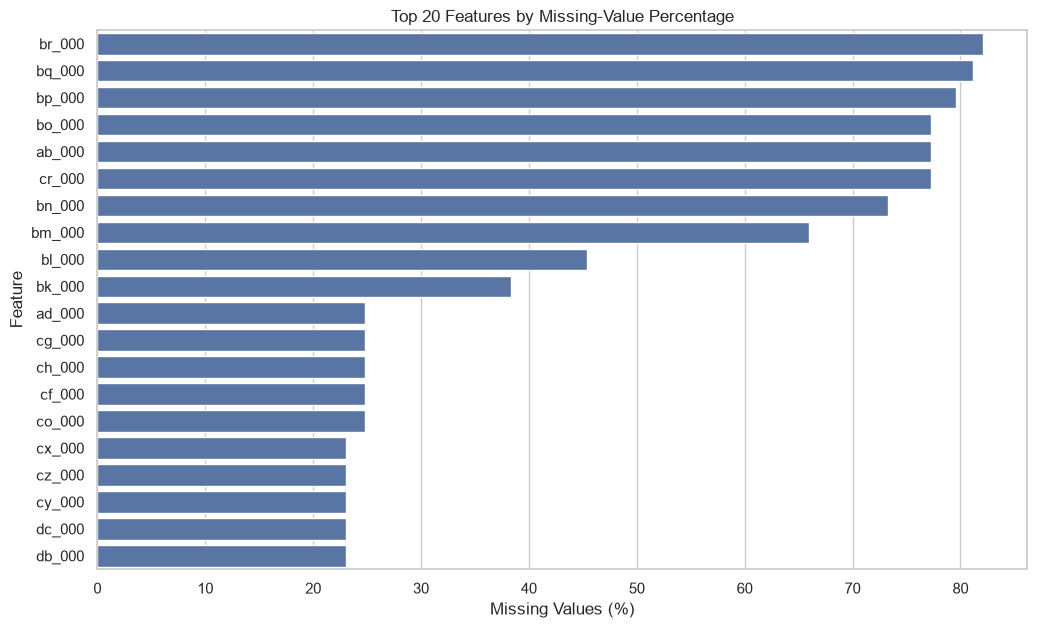

In [10]:
top_missing = missing_summary.head(20)

plt.figure(figsize=(12, 7))
sns.barplot(
    x=top_missing["Missing_Percentage"],
    y=top_missing.index
)
plt.title("Top 20 Features by Missing-Value Percentage")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.show()


## 6. Convert `na` to Missing Values and Convert Features to Numeric

This is a data-cleaning step. We do not impute values yet; first we inspect the cleaned data and decide the preprocessing strategy.


In [11]:
df_clean = df.copy()

# Convert the dataset's "na" representation to actual missing values.
df_clean = df_clean.replace("na", np.nan)

# Convert all feature columns to numeric.
feature_cols = [c for c in df_clean.columns if c != "class"]
df_clean[feature_cols] = df_clean[feature_cols].apply(
    pd.to_numeric, errors="coerce"
)

# Encode the target.
df_clean["class"] = df_clean["class"].map({"neg": 0, "pos": 1})

print(df_clean.shape)
print(df_clean["class"].value_counts(dropna=False))


(76000, 171)
class
0    74625
1     1375
Name: count, dtype: int64


In [12]:
missing_clean = df_clean.isna().sum()
missing_clean_pct = (missing_clean / len(df_clean)) * 100

missing_clean_summary = pd.DataFrame({
    "Missing_Count": missing_clean,
    "Missing_Percentage": missing_clean_pct
}).sort_values("Missing_Percentage", ascending=False)

display(missing_clean_summary.head(30))


,Missing_Count,Missing_Percentage
br_000,62393,82.096053
bq_000,61703,81.188158
bp_000,60461,79.553947
bo_000,58709,77.248684
ab_000,58692,77.226316
cr_000,58692,77.226316
bn_000,55722,73.318421
bm_000,50095,65.914474
bl_000,34503,45.398684
bk_000,29128,38.326316


## 7. Statistical Summary

In [13]:
X_raw = df_clean.drop(columns="class")

display(X_raw.describe().T)


,count,mean,std,min,25%,50%,75%,max
aa_000,76000.0,6.115976e+04,2.647366e+05,0.0,860.0,30813.0,48840.0,4.294967e+07
ab_000,17308.0,7.255604e-01,3.311913e+00,0.0,0.0,0.0,0.0,2.040000e+02
ac_000,71739.0,3.564398e+08,7.952530e+08,0.0,16.0,154.0,970.0,2.130707e+09
ad_000,57158.0,1.506300e+05,3.590593e+07,0.0,24.0,128.0,430.0,8.584298e+09
ae_000,72810.0,6.736959e+00,1.534465e+02,0.0,0.0,0.0,0.0,2.105000e+04
...,...,...,...,...,...,...,...,...
ee_007,75137.0,3.475611e+05,1.707593e+06,0.0,112.0,41260.0,168046.0,1.195801e+08
ee_008,75137.0,1.398968e+05,4.692327e+05,0.0,0.0,3862.0,139500.0,1.926740e+07
ee_009,75137.0,8.424984e+03,4.875440e+04,0.0,0.0,0.0,2000.0,4.570398e+06
ef_000,72514.0,8.519734e-02,4.179600e+00,0.0,0.0,0.0,0.0,4.820000e+02


## 8. Low-Variance Feature Analysis

In [14]:
feature_variance = X_raw.var(numeric_only=True).sort_values()

display(feature_variance.head(20))


cd_000    0.000000e+00
ch_000    9.095679e-04
ab_000    1.096876e+01
ef_000    1.746906e+01
ar_000    2.844198e+01
eg_000    1.047972e+02
dz_000    1.081894e+02
ea_000    2.654759e+03
db_000    4.365715e+03
ae_000    2.354582e+04
af_000    4.064048e+04
da_000    4.616273e+04
cg_000    1.387195e+05
bf_000    3.027381e+05
cr_000    1.081011e+06
ax_000    2.209536e+06
de_000    2.634282e+06
cm_000    3.169233e+06
cs_001    7.653140e+06
az_009    8.703563e+06
dtype: float64

Low-variance features are inspected rather than automatically deleted. A sensor feature with low variance may still be useful for a classifier, so removal should be justified.


## 9. Feature Distribution Analysis

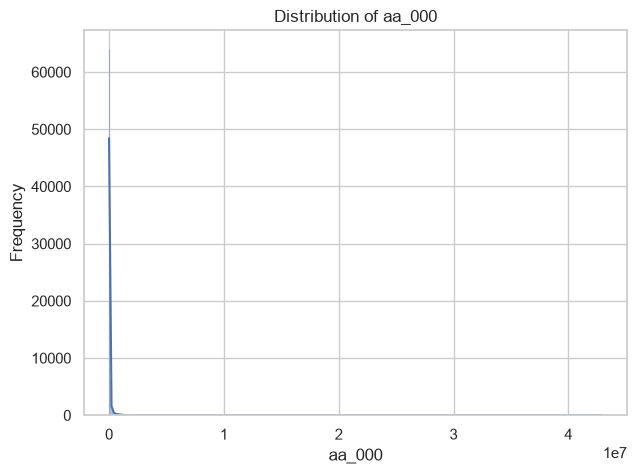

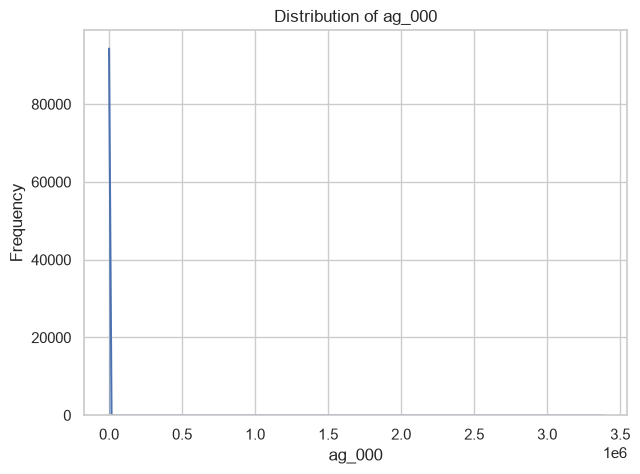

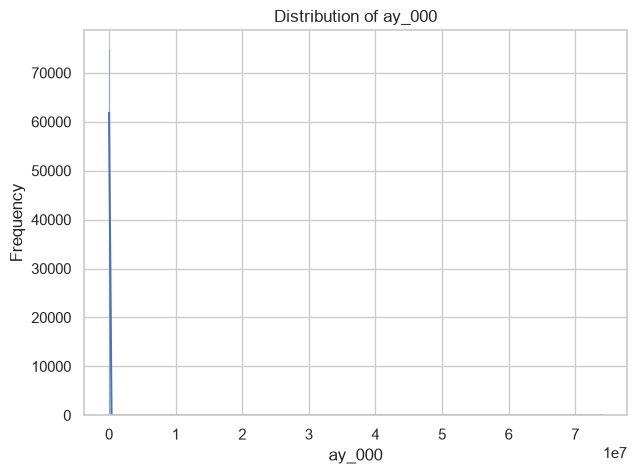

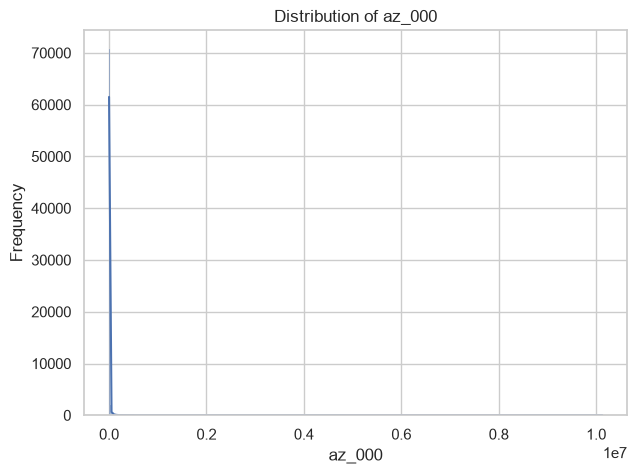

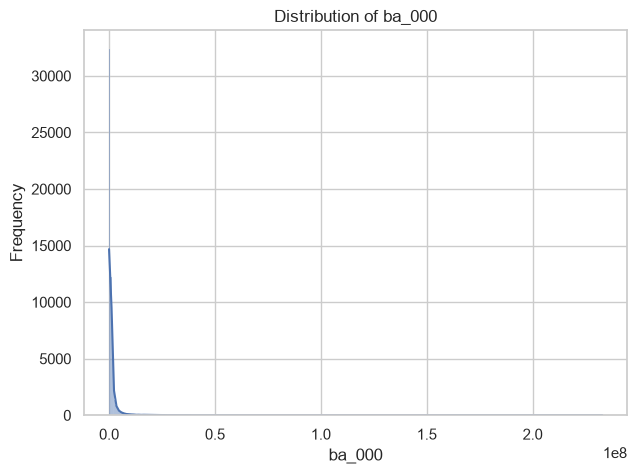

In [15]:
# Plot a small representative set first instead of plotting all 170 features.
candidate_features = [
    c for c in ["aa_000", "ag_000", "ay_000", "az_000", "ba_000"]
    if c in X_raw.columns
]

for col in candidate_features:
    plt.figure(figsize=(7, 5))
    sns.histplot(X_raw[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


## 10. Outlier Analysis

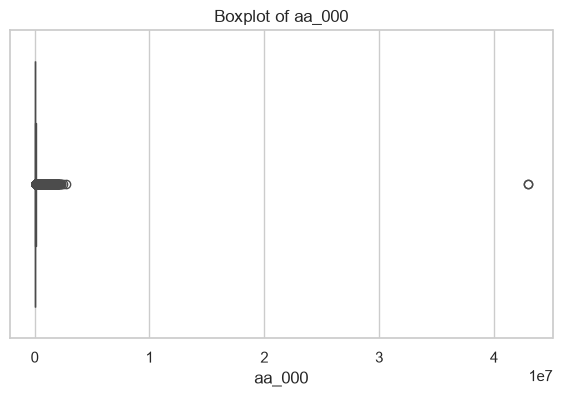

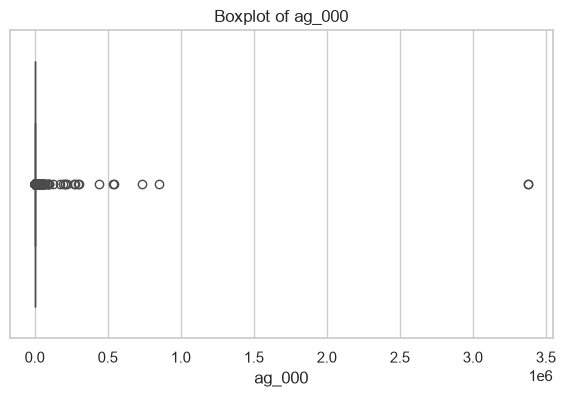

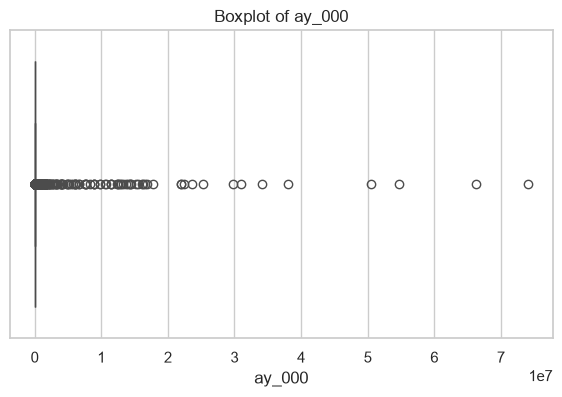

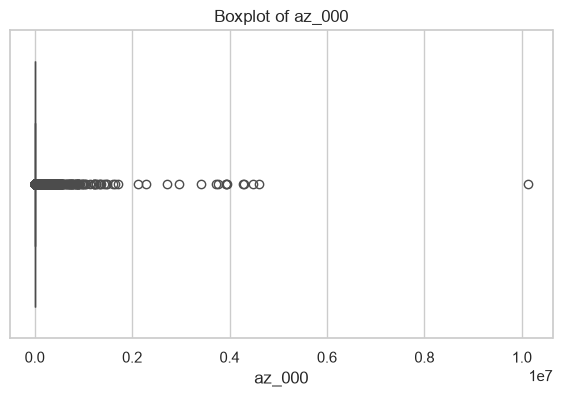

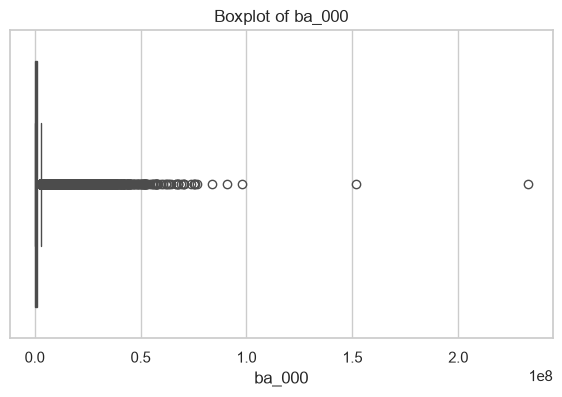

In [16]:
for col in candidate_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=X_raw[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()


### Outlier Decision

Do not automatically remove every extreme value. In vehicle sensor data, an extreme measurement can represent a genuine abnormal operating condition that may be useful for failure prediction. We will therefore retain values unless the EDA identifies clear evidence of invalid measurements.


## 11. Correlation Analysis

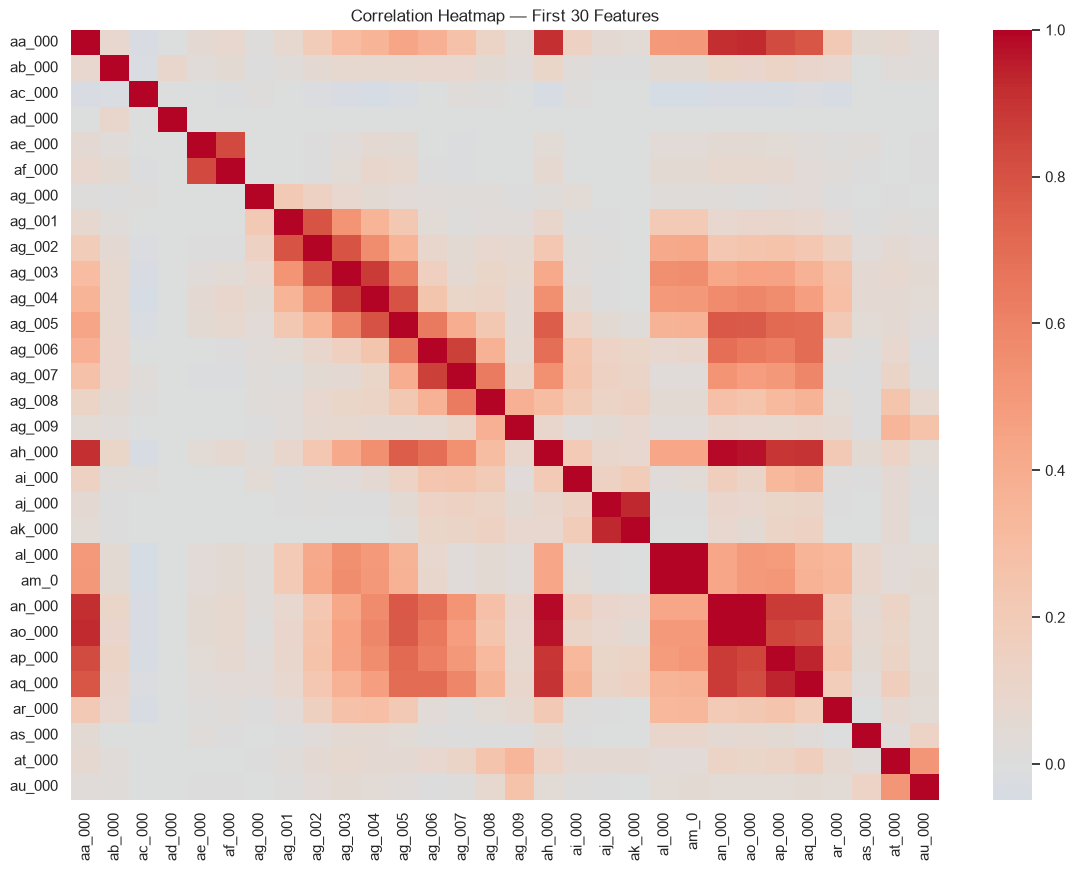

In [17]:
corr = X_raw.corr(numeric_only=True)

# Display correlations among the first 30 features for readability.
plt.figure(figsize=(14, 10))
sns.heatmap(corr.iloc[:30, :30], cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — First 30 Features")
plt.show()


In [18]:
# Find highly correlated feature pairs.
threshold = 0.90
high_corr_pairs = []

cols = corr.columns
for i in range(len(cols)):
    for j in range(i):
        value = corr.iloc[i, j]
        if pd.notna(value) and abs(value) >= threshold:
            high_corr_pairs.append((cols[i], cols[j], value))

high_corr_pairs = sorted(
    high_corr_pairs,
    key=lambda x: abs(x[2]),
    reverse=True
)

print("Number of highly correlated pairs:", len(high_corr_pairs))
display(pd.DataFrame(
    high_corr_pairs[:30],
    columns=["Feature_1", "Feature_2", "Correlation"]
))


Number of highly correlated pairs: 142


,Feature_1,Feature_2,Correlation
0,bv_000,bb_000,1.000000
1,bg_000,ah_000,1.000000
2,bt_000,aa_000,1.000000
3,cq_000,bv_000,1.000000
4,cq_000,bb_000,1.000000
5,cq_000,bu_000,1.000000
6,bv_000,bu_000,1.000000
7,bu_000,bb_000,1.000000
8,co_000,cf_000,1.000000
9,cf_000,ad_000,1.000000


## 12. Train-Test Split

Because this combined file contains the target labels, we create our own stratified split for the project. The test set will remain untouched while preprocessing parameters are learned from the training set.


In [19]:
X = df_clean.drop(columns="class")
y = df_clean["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTraining class distribution:")
display(y_train.value_counts())

print("\nTesting class distribution:")
display(y_test.value_counts())


X_train: (60800, 170)
X_test : (15200, 170)
y_train: (60800,)
y_test : (15200,)

Training class distribution:


class
0    59700
1     1100
Name: count, dtype: int64


Testing class distribution:


class
0    14925
1      275
Name: count, dtype: int64

## 13. Missing-Value Preprocessing

A median imputer is fitted **only on the training data**. The same learned medians are then applied to the test data. This avoids using information from the test set during training.


In [20]:
# Check how many columns have missing values in the training data.
train_missing_pct = X_train.isna().mean() * 100

display(
    train_missing_pct.sort_values(ascending=False).head(30).to_frame("Training_Missing_%")
)


,Training_Missing_%
br_000,82.113487
bq_000,81.226974
bp_000,79.597039
bo_000,77.314145
ab_000,77.250000
cr_000,77.250000
bn_000,73.368421
bm_000,66.023026
bl_000,45.381579
bk_000,38.299342


In [21]:
# Initial, conservative approach:
# retain features and impute numerical missing values using the training median.
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("Training data after imputation:", X_train_imputed.shape)
print("Testing data after imputation :", X_test_imputed.shape)


Training data after imputation: (60800, 170)
Testing data after imputation : (15200, 170)


## 14. Feature Scaling

Scaling is model-dependent. It is useful for models such as Logistic Regression and SVM, while tree-based models generally do not require it.

The scaled matrices below are intended for scale-sensitive models.


In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape :", X_test_scaled.shape)


Scaled training shape: (60800, 170)
Scaled testing shape : (15200, 170)


## 15. Class Imbalance Check After Split

In [23]:
print("Training class distribution:")
print(y_train.value_counts())
print()

print("Training class percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2))


Training class distribution:
class
0    59700
1     1100
Name: count, dtype: int64

Training class percentages:
class
0    98.19
1     1.81
Name: proportion, dtype: float64


### Imbalance Strategy

The positive APS-failure class is much smaller than the negative class. For the first model baseline, use class-weighted algorithms rather than applying SMOTE blindly. SMOTE can be evaluated later as a separate experiment if required.


## 16. Save Processed Data

In [24]:
# Preserve feature names after preprocessing.
feature_names = X_train.columns.tolist()

X_train_processed_df = pd.DataFrame(
    X_train_imputed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_imputed,
    columns=feature_names,
    index=X_test.index
)

X_train_processed_df.to_csv("X_train_processed.csv", index=False)
X_test_processed_df.to_csv("X_test_processed.csv", index=False)

pd.Series(
    y_train.to_numpy(),
    name="class"
).to_csv("y_train.csv", index=False)

pd.Series(
    y_test.to_numpy(),
    name="class"
).to_csv("y_test.csv", index=False)

print("Processed APS Scania training and testing files saved successfully!")


Processed APS Scania training and testing files saved successfully!


## 17. Final Preprocessing Summary

### Completed
- Loaded the combined APS Scania dataset
- Inspected shape, columns and data types
- Analyzed target distribution
- Identified the `na` missing-value representation
- Converted missing values to `NaN`
- Converted sensor features to numeric
- Encoded `neg`/`pos` as 0/1
- Performed statistical, distribution, outlier and correlation analysis
- Created a stratified 80/20 train-test split
- Applied median imputation using training data only
- Prepared scaled data for scale-sensitive ML models
- Saved processed training/test feature and target files

### Important
Class-imbalance handling is intentionally kept as a model-development experiment rather than modifying the test data. Model training and evaluation should be done in the next notebook section.
